# Task 1 : Building recommender Models and Evaluation

---
### 0. Import & Config

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from surprise import KNNBasic, Dataset, Reader, SVD, accuracy
from surprise.model_selection import train_test_split, GridSearchCV
from collections import defaultdict

# paths creation 

path = r'C:\Users\ephts\OneDrive\Documents\Master UA\Data mining\A2' 

data_path = os.path.join(path, 'datas') 
output = os.path.join(path, 'output') 
preprocessed = os.path.join(path, 'preprocessed') 
figures = os.path.join(path, 'fig') 

MOVIES_PATH = os.path.join(preprocessed, 'movies.csv') 
RATINGS_TRAIN_PATH = os.path.join(preprocessed, 'ratings_train.csv') 
RATINGS_TEST_PATH = os.path.join(data_path, 'ratings_test.csv')

print('Imported and paths created')

Imported and paths created


---
### 1. Loading datas

In [18]:
movies = pd.read_csv(MOVIES_PATH) 
ratings_train = pd.read_csv(RATINGS_TRAIN_PATH) 
ratings_test = pd.read_csv(RATINGS_TEST_PATH) 

print('Datas loaded') 
print("------MOVIES--------") 
print(f'movies : {movies.shape}') 
display(movies.head()) 

print("------RATINGS TRAIN--------") 
print(f'ratings_train : {ratings_train.shape}') 
display(ratings_train.head()) 

print("------RATINGS TEST--------") 
print(f'ratings_test : {ratings_test.shape}') 
display(ratings_test.head())

Datas loaded
------MOVIES--------
movies : (9742, 24)


,movieId,title,genres,year,title_clean,genre_Action,genre_Adventure,genre_Animation,genre_Children,genre_Comedy,...,genre_Film-Noir,genre_Horror,genre_IMAX,genre_Musical,genre_Mystery,genre_Romance,genre_Sci-Fi,genre_Thriller,genre_War,genre_Western
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995.0,Toy Story,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,Jumanji (1995),Adventure|Children|Fantasy,1995.0,Jumanji,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,3,Grumpier Old Men (1995),Comedy|Romance,1995.0,Grumpier Old Men,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,1995.0,Waiting to Exhale,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
4,5,Father of the Bride Part II (1995),Comedy,1995.0,Father of the Bride Part II,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


------RATINGS TRAIN--------
ratings_train : (97801, 4)


,Unnamed: 0,userId,movieId,rating
0,0,1,1,4.0
1,1,1,3,4.0
2,2,1,6,4.0
3,3,1,47,5.0
4,4,1,50,5.0


------RATINGS TEST--------
ratings_test : (100, 11)


,userId,recommendation1,recommendation2,recommendation3,recommendation4,recommendation5,recommendation6,recommendation7,recommendation8,recommendation9,recommendation10
0,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
### 2. Prepare data for Surprise

In [19]:


# Only keep required columns
df = ratings_train[['userId', 'movieId', 'rating']]

# Define rating scale
reader = Reader(rating_scale=(df['rating'].min(), df['rating'].max()))

# Load dataset into Surprise
data = Dataset.load_from_df(df, reader)

# Train/test split 80/20
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

print("Data prepared for Surprise")
print(f"Train size: {trainset.n_ratings}")
print(f"Test size : {len(testset)}")

Data prepared for Surprise
Train size: 78240
Test size : 19561


---
### 3. Model 1 - KNN

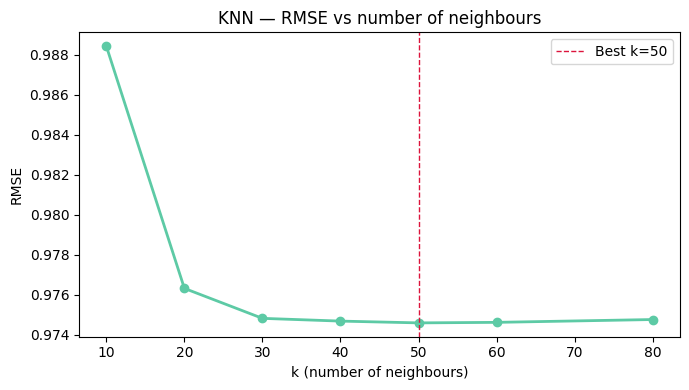

Best k: 50  (RMSE: 0.9746)
Best on this, we therefore know that k=50 is the best option for us


In [20]:
### Hyperparameter tuning KNN — RMSE vs k
k_values = [10, 20, 30, 40, 50, 60, 80]
rmse_values = []

#observe knn with different k_values
for k_val in k_values:
    model = KNNBasic(
        k=k_val, min_k=3,
        sim_options={'name': 'pearson', 'user_based': True},
        verbose=False
    )
    model.fit(trainset)
    preds = model.test(testset)
    rmse_values.append(accuracy.rmse(preds, verbose=False))

# Plot
plt.figure(figsize=(7, 4))
plt.plot(k_values, rmse_values, marker='o', color='#5DCAA5', linewidth=2)
plt.axvline(x=k_values[np.argmin(rmse_values)], color='crimson',
            linestyle='--', linewidth=1, label=f'Best k={k_values[np.argmin(rmse_values)]}')

dest = os.path.join(figures, 'knn_rmse.png')
plt.xlabel('k (number of neighbours)')
plt.ylabel('RMSE')
plt.title('KNN — RMSE vs number of neighbours')
plt.legend()
plt.tight_layout()
plt.savefig(dest)
plt.show()

best_k = k_values[np.argmin(rmse_values)]
print(f'Best k: {best_k}  (RMSE: {min(rmse_values):.4f})')
print('Best on this, we therefore know that k=50 is the best option for us')

In [21]:
# KNN (user-based)

from surprise import KNNBasic

sim_options = {
    'name': 'pearson',
    'user_based': True
}

knn = KNNBasic(
    k=50,
    min_k=3,
    sim_options=sim_options,
    verbose=True
)

knn.fit(trainset)

pred_knn = knn.test(testset)

print("KNN model trained")

Computing the pearson similarity matrix...
Done computing similarity matrix.
KNN model trained


---
### 4. Model 2 - SVD

In [22]:
# First we try to find the hyperparameters that optimize SVD


df = ratings_train[['userId', 'movieId', 'rating']]
reader = Reader(rating_scale=(df['rating'].min(), df['rating'].max()))
data = Dataset.load_from_df(df, reader)

# different possibles set of hyperparameters
param_grid = {
    'n_factors': [20, 50, 100],
    'n_epochs': [20, 30],
    'lr_all': [0.002, 0.005, 0.01],
    'reg_all': [0.02, 0.05, 0.1]
}


gs = GridSearchCV(
    SVD,
    param_grid,
    measures=['rmse'],
    cv=3,
    joblib_verbose=1
)

gs.fit(data)

print("Best RMSE:", gs.best_score['rmse'])
print("Best params:", gs.best_params['rmse'])

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:   40.4s


Best RMSE: 0.864664236246429
Best params: {'n_factors': 50, 'n_epochs': 30, 'lr_all': 0.01, 'reg_all': 0.1}


[Parallel(n_jobs=1)]: Done 162 out of 162 | elapsed:  2.6min finished


In [23]:
# SVD


best_params = gs.best_params['rmse']

svd = SVD(
    n_factors=best_params['n_factors'],
    n_epochs=best_params['n_epochs'],
    lr_all=best_params['lr_all'],
    reg_all=best_params['reg_all'],
    random_state=42
)
svd.fit(trainset)

pred_svd = svd.test(testset)

print("SVD model trained")


SVD model trained


---

### 5. RMSE Evaluation

In [24]:
# Compute and compare the Root Mean Squared Error (RMSE)
# Lower RMSE -> higher accuracy
print("----- RMSE -----")

rmse_knn = accuracy.rmse(pred_knn)
rmse_svd = accuracy.rmse(pred_svd)

results_rmse = pd.DataFrame({
    'Model': ['KNN (user-based)', 'SVD'],
    'RMSE': [rmse_knn, rmse_svd]
})

display(results_rmse.sort_values('RMSE'))

----- RMSE -----
RMSE: 0.9746
RMSE: 0.8660


,Model,RMSE
1,SVD,0.865971
0,KNN (user-based),0.974591


---
### 6. Precision@K // Recall@K

In [25]:

def precision_recall_at_k(predictions, k=10, threshold=4.0):
    '''
    Define a custom function to calculate ranking-based metrics at a threshold of 4.0
    Precision@10 measures relevance, while Recall@10 measures the coverage of liked items
    '''
    user_est_true = defaultdict(list)

    for uid, iid, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions = []
    recalls = []

    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)

        n_rel = sum(true_r >= threshold for (_, true_r) in user_ratings)
        top_k = user_ratings[:k]

        n_rec_k = sum(est >= threshold for (est, _) in top_k)
        n_rel_and_rec_k = sum(
            (true_r >= threshold and est >= threshold)
            for (est, true_r) in top_k
        )

        precision = n_rel_and_rec_k / n_rec_k if n_rec_k else 0
        recall = n_rel_and_rec_k / n_rel if n_rel else 0

        precisions.append(precision)
        recalls.append(recall)

    return np.mean(precisions), np.mean(recalls)


k = 10

p_knn, r_knn = precision_recall_at_k(pred_knn, k=k)
p_svd, r_svd = precision_recall_at_k(pred_svd, k=k)

results_pr = pd.DataFrame({
    'Model': ['KNN (user-based)', 'SVD'],
    f'Precision@{k}': [p_knn, p_svd],
    f'Recall@{k}': [r_knn, r_svd]
})

display(results_pr)

,Model,Precision@10,Recall@10
0,KNN (user-based),0.655381,0.293693
1,SVD,0.577481,0.293841


---
### 7. Diversity

In [26]:
# Extract top-K recommendations and calculate the genre variety for each user


def get_top_k_recs(predictions, k=10):
    user_recs = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        user_recs[uid].append((iid, est))
    return {
        uid: [iid for iid, _ in sorted(recs, key=lambda x: x[1], reverse=True)[:k]]
        for uid, recs in user_recs.items()
    }
    
def diversity_score(movie_ids):
    genres = movies[movies['movieId'].isin(movie_ids)]['genres']
    
    all_genres = set()
    for g in genres:
        all_genres.update(g.split('|'))
    
    return len(all_genres)

def mean_diversity(predictions, k=10):
    """Average diversity score across all users."""
    top_k = get_top_k_recs(predictions, k=k)
    scores = [diversity_score(movie_ids) for movie_ids in top_k.values()]
    return np.mean(scores)

K=k
div_knn = mean_diversity(pred_knn, k=K)
div_svd = mean_diversity(pred_svd, k=K)

# Version correcte
print(f'Mean diversity@{K}  —  KNN: {div_knn:.2f}  |  SVD: {div_svd:.2f}')

Mean diversity@10  —  KNN: 10.07  |  SVD: 10.15


---
### 8. Novelty

In [27]:
# Calculate novelty using the -log2(popularity) formula 

n_users_train = ratings_train['userId'].nunique()
popularity    = ratings_train.groupby('movieId').size() / n_users_train

def novelty_score(movie_ids):
    scores = []
    for mid in movie_ids:
        p = popularity.get(mid, 1e-10)
        scores.append(-np.log2(p))
    return np.mean(scores)

def mean_novelty(predictions, k=10):
    top_k = get_top_k_recs(predictions, k=k)
    return np.mean([novelty_score(ids) for ids in top_k.values()])

nov_knn = mean_novelty(pred_knn, k=K)
nov_svd = mean_novelty(pred_svd, k=K)

print(f'Mean novelty@{K}  —  KNN: {nov_knn:.2f}  |  SVD: {nov_svd:.2f}')

Mean novelty@10  —  KNN: 3.28  |  SVD: 3.28


---
### 9. Compare Models

In [28]:
#create table with all metrics
comparison = pd.DataFrame({
    'Model'          : ['KNN (user-based)', 'SVD'],
    'RMSE'           : [rmse_knn, rmse_svd],
    f'Precision@{K}' : [p_knn,   p_svd],
    f'Recall@{K}'    : [r_knn,   r_svd],
    f'Diversity@{K}' : [div_knn, div_svd],
    f'Novelty@{K}'   : [nov_knn, nov_svd],
})
display(comparison)

best_model_name = comparison.sort_values(
    by=[f'Precision@{K}', f'Recall@{K}', 'RMSE'],
    ascending=[False, False, True]
).iloc[0]['Model']

print(f"Best model: {best_model_name}")

,Model,RMSE,Precision@10,Recall@10,Diversity@10,Novelty@10
0,KNN (user-based),0.974591,0.655381,0.293693,10.066778,3.279637
1,SVD,0.865971,0.577481,0.293841,10.148581,3.284519


Best model: KNN (user-based)


---
### 10. Visualisation

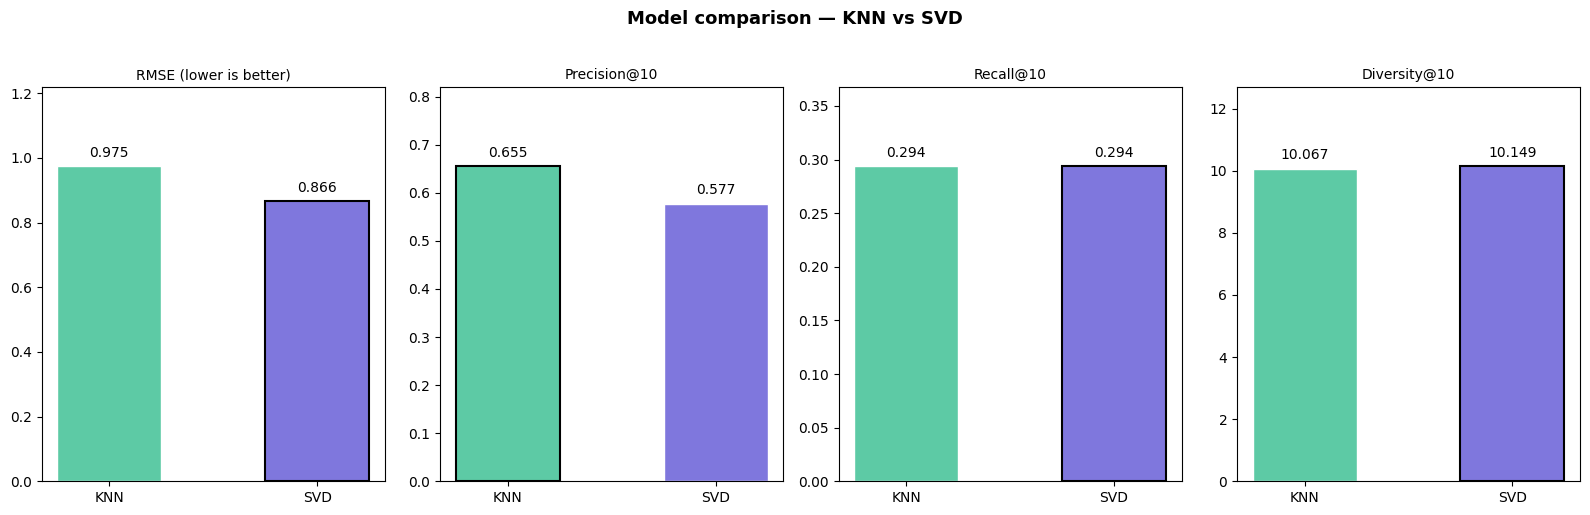

In [29]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
models  = ['KNN', 'SVD']
colors  = ['#5DCAA5', '#7F77DD']

metrics = [
    ('RMSE',            [rmse_knn, rmse_svd], True,  'RMSE (lower is better)'),
    (f'Precision@{K}',  [p_knn,   p_svd],    False, f'Precision@{K}'),
    (f'Recall@{K}',     [r_knn,   r_svd],    False, f'Recall@{K}'),
    (f'Diversity@{K}',  [div_knn, div_svd],  False, f'Diversity@{K}'),
]

for ax, (metric, values, lower_better, title) in zip(axes, metrics):
    bars = ax.bar(models, values, color=colors, edgecolor='white', width=0.5)
    ax.set_title(title, fontsize=10)
    ax.set_ylim(0, max(values) * 1.25)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(values) * 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10)
    best_idx = np.argmin(values) if lower_better else np.argmax(values)
    bars[best_idx].set_edgecolor('black')
    bars[best_idx].set_linewidth(1.5)

save_dst = os.path.join(figures,'compare_knn_svd.png')
plt.suptitle('Model comparison — KNN vs SVD', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(save_dst)
plt.show()


---
### Storage
 Keep best model name for further uses

In [30]:
import json

with open("best_model.json", "w") as f:
    json.dump({"best_model": best_model_name}, f)

print("Stored")

Stored
